In [1]:
#Imports Iniciales

#!pip install optuna

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import optuna
from optuna.samplers import TPESampler
from sklearn.svm import SVC
from sklearn.base import clone

In [2]:
# Read CSV file into a DataFrame
df_metadata = pd.read_csv('SraRunTable.csv')

df_metadata["disease_status"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(Patient|Control)", expand=False)
    .str.lower()
)

df_metadata["disease_status"] = df_metadata["disease_status"].map({
    "control": 0,
    "patient": 1
})

df_metadata["pair_id"] = (
    df_metadata["Sample Name"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

df_metadata = df_metadata[["Run", "env_medium", "disease_status","pair_id"]]

df_metadata

,Run,env_medium,disease_status,pair_id
0,SRR32936395,Unstimulated saliva,1,17
1,SRR32936396,Unstimulated saliva,0,16
2,SRR32936397,Unstimulated saliva,1,3
3,SRR32936398,Unstimulated saliva,1,16
4,SRR32936408,Unstimulated saliva,1,2
...,...,...,...,...
247,SRR32938727,Supragingival swab,0,6
248,SRR32938728,Supragingival swab,1,6
249,SRR32938729,Supragingival swab,0,5
250,SRR32938733,Supragingival swab,1,4


In [3]:
df_asv = pd.read_csv('asv_table.tsv', sep = '\t', header=1)
df_asvt = df_asv.transpose()
new_header = df_asvt.iloc[0] 
df_asvt = df_asvt[1:] 
df_asvt.columns = new_header
df_asvt.reset_index(level=0, inplace=True, names=["Run"]) 
df_asvt.head()

#OTU ID,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,58844abe1585eaed470c626af5e293c2,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,37e7e601cfd657b615591af65747ff4d,e99ef6d33371880af23ceea3cfd58e56,...,ad98578086fac11d2c8d482bac525d19,a094de4e58b9f291cdea1600e53ae871,518528979dc71666ec2bba322b9e806b,dec2a6a67a2a8cb475b16c04cd60c712,30a3a61dfd94eef22b368c4e078bcdf2,19322f53614269ad24c1b6e83d85b1a8,8d451bdf92f1a3f59016162bd25ddb2b,234ba3e9c68c5efdb496a08c06eb4fd1,580a3724eadd91834f6b885e8132c4d3,e8035cd0cf8992d4de5c688f1923022a
0,SRR32936402,9477.0,9235.0,8983.0,8878.0,7642.0,7406.0,5917.0,4881.0,4300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,0.0,945.0,9364.0,0.0,0.0,782.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,0.0,811.0,7265.0,11794.0,4946.0,0.0,574.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,0.0,7772.0,19553.0,5817.0,11248.0,0.0,408.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,0.0,6106.0,26832.0,6933.0,17034.0,0.0,2117.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


ASVs con prevalencia ≥ 20%: 552
ASVs totales: 8574
Porcentaje conservado: 6.44%


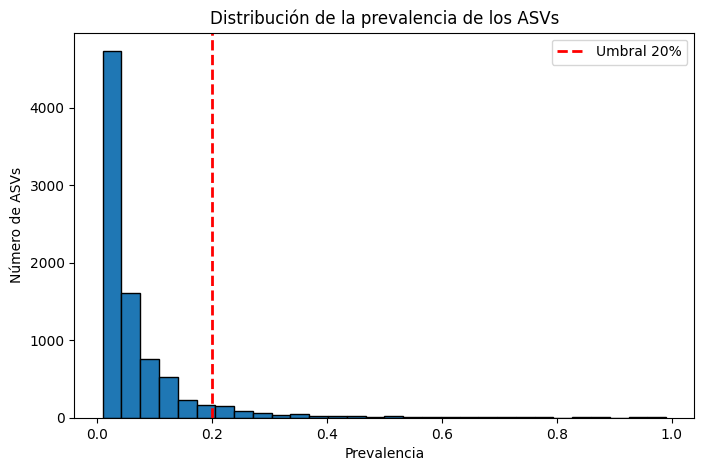

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Quedarse solo con las columnas de ASVs
asv_counts = df_asvt.drop(columns=["Run"])

# Prevalencia de cada ASV (fracción de muestras donde el conteo > 0)
prevalence = (asv_counts > 0).mean(axis=0)

# Número de ASVs que superan el 20%
n_asvs = (prevalence >= 0.2).sum()

print(f"ASVs con prevalencia ≥ 20%: {n_asvs}")
print(f"ASVs totales: {asv_counts.shape[1]}")
print(f"Porcentaje conservado: {100*n_asvs/asv_counts.shape[1]:.2f}%")

# Histograma de prevalencias
plt.figure(figsize=(8,5))
plt.hist(prevalence, bins=30, edgecolor="black")
plt.axvline(0.2, color="red", linestyle="--", linewidth=2,
            label="Umbral 20%")
plt.xlabel("Prevalencia")
plt.ylabel("Número de ASVs")
plt.title("Distribución de la prevalencia de los ASVs")
plt.legend()
plt.show()

In [5]:
# Seleccionar ASVs con prevalencia ≥ 20%
asv_counts_filtered = asv_counts.loc[:, prevalence >= 0.20]

# Comprobar resultados
print(f"ASVs después del filtrado: {asv_counts_filtered.shape[1]}")
print(f"ASVs eliminados: {asv_counts.shape[1] - asv_counts_filtered.shape[1]}")
print(f"Porcentaje conservado: {100*asv_counts_filtered.shape[1]/asv_counts.shape[1]:.2f}%")

# Si quieres volver a incluir la columna Run:
df_asvt_filtered = pd.concat([df_asvt["Run"], asv_counts_filtered], axis=1)
df_asvt_filtered.head()

ASVs después del filtrado: 552
ASVs eliminados: 8022
Porcentaje conservado: 6.44%


,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,25a739f236938a52b28895558f2f4c65,626145cc8bcaf0764330664a8ca9266b,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623
0,SRR32936402,9477.0,9235.0,8878.0,7642.0,7406.0,5917.0,4300.0,3838.0,3437.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,SRR32936389,0.0,2047.0,0.0,945.0,9364.0,0.0,782.0,164.0,2054.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SRR32938709,0.0,234.0,811.0,7265.0,11794.0,4946.0,574.0,1870.0,489.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SRR32936396,12181.0,338.0,7772.0,19553.0,5817.0,11248.0,408.0,1771.0,876.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SRR32936412,17581.0,1706.0,6106.0,26832.0,6933.0,17034.0,2117.0,2359.0,3806.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#CLR transform

runs = df_asvt_filtered["Run"]

df_asvtclr = df_asvt_filtered.drop(columns="Run").astype(float)

df_asvtclr = df_asvtclr + 1

gm = np.exp(np.log(df_asvtclr).mean(axis=1))

df_asvtclr = np.log(df_asvtclr.div(gm, axis=0))

df_asvtclr.insert(0, "Run", runs)

df_asvtclr.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,25a739f236938a52b28895558f2f4c65,626145cc8bcaf0764330664a8ca9266b,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041


In [7]:
#merge de ambas columnas
mg = pd.merge(df_asvtclr, df_metadata, on="Run", how="left")
mg

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,env_medium,disease_status,pair_id
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,Unstimulated saliva,1,14
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,Unstimulated saliva,1,20
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,Supragingival swab,1,15
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,Unstimulated saliva,0,16
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,Unstimulated saliva,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,SRR32936397,7.272687,5.253448,5.435925,7.422768,7.782894,7.685705,5.271899,5.726705,6.115402,...,3.134115,-1.725697,-1.725697,2.550969,2.631012,-0.339403,-1.725697,Unstimulated saliva,1,3
97,SRR32938719,-1.496125,5.683182,3.831751,7.928762,8.945170,6.510909,5.167007,6.275785,5.445065,...,-1.496125,1.969610,-1.496125,-1.496125,-1.496125,-1.496125,-1.496125,Supragingival swab,0,10
98,SRR32936399,5.863502,6.220812,-1.497873,7.932084,7.217351,7.530225,1.637621,5.964916,6.168348,...,2.191006,-0.399261,-1.497873,1.497859,-1.497873,-1.497873,3.361939,Unstimulated saliva,0,15
99,SRR32938700,-1.413184,0.784041,-1.413184,5.850846,9.801228,5.005181,3.924354,3.722615,5.275171,...,1.764870,-1.413184,-1.413184,1.631339,-1.413184,2.324486,-1.413184,Supragingival swab,1,19


In [8]:
#ohe
df_analisis_ohe = pd.get_dummies(mg, columns= ['env_medium'], drop_first=False)
df_analisis_ohe.head()

,Run,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,...,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,disease_status,pair_id,env_medium_Supragingival swab,env_medium_Unstimulated saliva
0,SRR32936402,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,1,14,False,True
1,SRR32936389,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,1,20,False,True
2,SRR32938709,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,1,15,True,False
3,SRR32936396,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,0,16,False,True
4,SRR32936412,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,0,9,False,True


In [9]:
# Variable objetivo
y = df_analisis_ohe["disease_status"]

# Grupos para los folds
groups = df_analisis_ohe["pair_id"]

# Variables predictoras
X = df_analisis_ohe.drop(columns=[
    "Run",
    "disease_status",
    "pair_id"
])
X

,afc7d633b31eacbcd06f9bd00fc92aba,d08c784d1836f43726d1162eadd9c4a4,b9678f89d81e366818a5f4e9a4dbcbf6,2f2af02b1b3b9b47876e1c1f5c41d976,3307f2605d463abcc42024cdfef4c1fe,0f36313fefd8246ebc2d63bd1b70b6f4,e99ef6d33371880af23ceea3cfd58e56,bccbf6a32db96f7b285bb310e4939979,2df318818bdb95fe9e968c46f24b6694,23e4c18880db9ea26fff40c84949538a,...,74925d8f20717e87ce604106d88cf028,3d2c71fbaf92c56b02e8a461e411901f,e5e617451fef60a6bf096cd5e879e5eb,af321296818b6f22280afe5ca810ec2e,37982d7213cf68b2468258261a050977,fe0d60c62bc7c9ce14dcb5cded7cddbd,9677c16ff1cbe3c88a8e53631965290d,c7aafba8d82d6edd5a180bb20191d623,env_medium_Supragingival swab,env_medium_Unstimulated saliva
0,7.826119,7.800255,7.760835,7.610936,7.579572,7.355145,7.035994,6.922358,6.812036,6.784613,...,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,-1.330609,False,True
1,-1.544053,6.080566,-1.544053,5.308190,7.600682,-1.544053,5.119080,3.561893,6.083978,-1.544053,...,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,-1.544053,False,True
2,-1.323049,4.136536,5.376451,7.567912,8.052382,7.183487,5.031321,6.211179,4.871356,-1.323049,...,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,-1.323049,True,False
3,8.202806,4.621091,7.753502,8.676026,7.463803,8.123126,4.808806,6.274955,5.571598,-1.204909,...,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,-1.204909,False,True
4,8.166590,5.834452,7.109150,8.589347,7.236151,8.134985,6.050187,6.158376,6.636556,-1.608041,...,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,-1.608041,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,7.272687,5.253448,5.435925,7.422768,7.782894,7.685705,5.271899,5.726705,6.115402,-1.725697,...,-1.725697,3.134115,-1.725697,-1.725697,2.550969,2.631012,-0.339403,-1.725697,False,True
97,-1.496125,5.683182,3.831751,7.928762,8.945170,6.510909,5.167007,6.275785,5.445065,-0.397513,...,-1.496125,-1.496125,1.969610,-1.496125,-1.496125,-1.496125,-1.496125,-1.496125,True,False
98,5.863502,6.220812,-1.497873,7.932084,7.217351,7.530225,1.637621,5.964916,6.168348,-1.497873,...,-0.804726,2.191006,-0.399261,-1.497873,1.497859,-1.497873,-1.497873,3.361939,False,True
99,-1.413184,0.784041,-1.413184,5.850846,9.801228,5.005181,3.924354,3.722615,5.275171,-1.413184,...,-1.413184,1.764870,-1.413184,-1.413184,1.631339,-1.413184,2.324486,-1.413184,True,False


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, balanced_accuracy_score


# Silenciar los mensajes de log informativos de Optuna para no saturar la pantalla
optuna.logging.set_verbosity(optuna.logging.WARNING)

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

best_models = []
scores = []
results = []

# Validación cruzada externa
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups), 1):
    print(f"\n--- Procesando Fold {fold} ---")
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    def objective(trial):

        params = {
            'C': trial.suggest_float('C', 1e-2, 1e3, log=True),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
        }
        
        gamma_type = trial.suggest_categorical('gamma_type', ['scale', 'auto', 'custom'])
        if gamma_type == 'custom':
            params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
        else:
            params['gamma'] = gamma_type

        inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = []

        for in_train_idx, in_val_idx in inner_cv.split(X_train, y_train, groups_train):
            X_in_train, X_val = X_train.iloc[in_train_idx], X_train.iloc[in_val_idx]
            y_in_train, y_val = y_train.iloc[in_train_idx], y_train.iloc[in_val_idx]

            model = Pipeline([
                ("scaler", StandardScaler()),
                ("svc", SVC(**params))
            ])

            model.fit(X_in_train, y_in_train)

            scores = model.decision_function(X_val)

            cv_scores.append(
                roc_auc_score(y_val, scores)
            )

        return np.mean(cv_scores)

    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=50)

    best_params = study.best_params
    
    # Ajustar el parámetro gamma según lo seleccionado por Optuna
    if best_params['gamma_type'] == 'custom':
        best_params['gamma'] = best_params.pop('gamma')
    else:
        best_params['gamma'] = best_params['gamma_type']
    del best_params['gamma_type']

    print(f"Mejores hiperparámetros: {best_params}")

    best_svc = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(**best_params))
    ])
    best_svc.fit(X_train, y_train)

    test_preds = best_svc.predict(X_test)

    test_scores = best_svc.decision_function(X_test)

    fold_auc = roc_auc_score(
        y_test,
        test_scores
    )

    fold_f1_weighted = f1_score(
        y_test, 
        test_preds, 
        average='weighted'
    )
    
    fold_f1_macro = f1_score(
        y_test, 
        test_preds, 
        average='macro'
    )
    
    fold_bal_acc = balanced_accuracy_score(
        y_test, 
        test_preds
    )
    
    # Guardar resultados del fold
    results.append({
        "fold": fold,
        "roc_auc": fold_auc,
        "f1_weighted": fold_f1_weighted,
        "f1_macro": fold_f1_macro,
        "balanced_accuracy": fold_bal_acc,
        "best_params": best_params
    })
    
    scores.append(fold_f1_weighted)
    best_models.append(best_svc)
    
    print(f"ROC-AUC      (Fold {fold}): {fold_auc:.4f}")
    print(f"F1 weighted  (Fold {fold}): {fold_f1_weighted:.4f}")
    print(f"F1 macro     (Fold {fold}): {fold_f1_macro:.4f}")
    print(f"Balanced Acc (Fold {fold}): {fold_bal_acc:.4f}")


--- Procesando Fold 1 ---
Mejores hiperparámetros: {'C': 0.0952393029718054, 'class_weight': None, 'gamma': 0.00020352548350100424}
ROC-AUC      (Fold 1): 0.7652
F1 weighted  (Fold 1): 0.3095
F1 macro     (Fold 1): 0.3235
Balanced Acc (Fold 1): 0.5000

--- Procesando Fold 2 ---
Mejores hiperparámetros: {'C': 498.3043837494905, 'class_weight': None, 'gamma': 'scale'}
ROC-AUC      (Fold 2): 0.8200
F1 weighted  (Fold 2): 0.8000
F1 macro     (Fold 2): 0.8000
Balanced Acc (Fold 2): 0.8000

--- Procesando Fold 3 ---
Mejores hiperparámetros: {'C': 0.7459343285726545, 'class_weight': None, 'gamma': 'scale'}
ROC-AUC      (Fold 3): 0.5700
F1 weighted  (Fold 3): 0.5833
F1 macro     (Fold 3): 0.5833
Balanced Acc (Fold 3): 0.6000

--- Procesando Fold 4 ---
Mejores hiperparámetros: {'C': 2.6855746553176525, 'class_weight': None, 'gamma': 0.00010815425103462295}
ROC-AUC      (Fold 4): 0.8250
F1 weighted  (Fold 4): 0.2735
F1 macro     (Fold 4): 0.3077
Balanced Acc (Fold 4): 0.5000

--- Procesando Fol

In [11]:
print(best_models)

[Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=0.0952393029718054, gamma=0.00020352548350100424))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=498.3043837494905))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=0.7459343285726545))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=2.6855746553176525, gamma=0.00010815425103462295))]), Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(C=5.1310600800916495, gamma=0.00016583271392830792))])]


In [12]:
#Comprobación de grupos
for train_idx, test_idx in outer_cv.split(X, y, groups):
    train_pairs = set(groups.iloc[train_idx])
    test_pairs = set(groups.iloc[test_idx])

    print(train_pairs.intersection(test_pairs))

set()
set()
set()
set()
set()


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_score,
    recall_score
)



# Definir modelo elegido


final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=19.724802059818767,
        gamma=0.00010103440325667329,
        class_weight="balanced"
    ))
])

In [14]:
# Validación cruzada 

outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)




y_true_all = []
y_pred_all = []
y_score_all = []

fold_results = []


from sklearn.base import clone

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups), 1
):

    print(f"\n--- Fold {fold} ---")

    # Crear modelo independiente
    model_fold = clone(final_model)


    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


    # Entrenar
    model_fold.fit(
        X_train,
        y_train
    )


    # Predicción clase
    y_pred = model_fold.predict(
        X_test
    )


    # Score continuo para ROC
    y_score = model_fold.decision_function(
        X_test
    )


    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
    y_score_all.extend(y_score)



    fold_auc = roc_auc_score(
        y_test,
        y_score
    )

    fold_bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    fold_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    fold_results.append({
        "fold": fold,
        "ROC-AUC": fold_auc,
        "Balanced Accuracy": fold_bal_acc,
        "F1 weighted": fold_f1
    })


    print(f"ROC-AUC: {fold_auc:.4f}")
    print(f"Balanced Accuracy: {fold_bal_acc:.4f}")
    print(f"F1 weighted: {fold_f1:.4f}")


--- Fold 1 ---
ROC-AUC: 0.7121
Balanced Accuracy: 0.6553
F1 weighted: 0.6509

--- Fold 2 ---
ROC-AUC: 0.7700
Balanced Accuracy: 0.7500
F1 weighted: 0.7494

--- Fold 3 ---
ROC-AUC: 0.4700
Balanced Accuracy: 0.5500
F1 weighted: 0.5396

--- Fold 4 ---
ROC-AUC: 0.7750
Balanced Accuracy: 0.7000
F1 weighted: 0.7083

--- Fold 5 ---
ROC-AUC: 0.6700
Balanced Accuracy: 0.6500
F1 weighted: 0.6491


In [15]:
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_score_all = np.array(y_score_all)


accuracy = accuracy_score(
    y_true_all,
    y_pred_all
)

balanced_acc = balanced_accuracy_score(
    y_true_all,
    y_pred_all
)

roc_auc = roc_auc_score(
    y_true_all,
    y_score_all
)

f1_macro = f1_score(
    y_true_all,
    y_pred_all,
    average="macro"
)

f1_weighted = f1_score(
    y_true_all,
    y_pred_all,
    average="weighted"
)

precision = precision_score(
    y_true_all,
    y_pred_all
)

recall = recall_score(
    y_true_all,
    y_pred_all
)


print(f"Accuracy:            {accuracy:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print(f"ROC-AUC:             {roc_auc:.4f}")
print(f"F1 macro:            {f1_macro:.4f}")
print(f"F1 weighted:         {f1_weighted:.4f}")
print(f"Precision:           {precision:.4f}")
print(f"Recall:              {recall:.4f}")


print("\nClassification report:\n")

print(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=[
            "Control",
            "Paciente"
        ]
    )
)


Accuracy:            0.6634
Balanced Accuracy:   0.6633
ROC-AUC:             0.6902
F1 macro:            0.6633
F1 weighted:         0.6634
Precision:           0.6667
Recall:              0.6667

Classification report:

              precision    recall  f1-score   support

     Control       0.66      0.66      0.66        50
    Paciente       0.67      0.67      0.67        51

    accuracy                           0.66       101
   macro avg       0.66      0.66      0.66       101
weighted avg       0.66      0.66      0.66       101



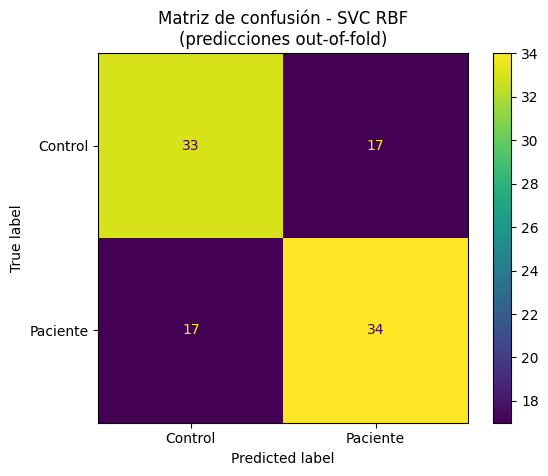

In [16]:
# Matriz de confusión


cm = confusion_matrix(
    y_true_all,
    y_pred_all
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Control",
        "Paciente"
    ]
)


disp.plot(
    values_format="d"
)

plt.title(
    "Matriz de confusión - SVC RBF\n(predicciones out-of-fold)"
)

plt.show()

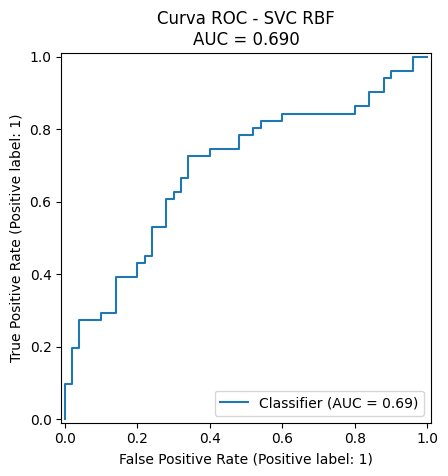

In [17]:
# Curva ROC

RocCurveDisplay.from_predictions(
    y_true_all,
    y_score_all
)

plt.title(
    f"Curva ROC - SVC RBF\nAUC = {roc_auc:.3f}"
)

plt.show()

In [18]:
# Tabla resumen de folds


fold_results = pd.DataFrame(
    fold_results
)

print("\nResultados por fold:")
display(fold_results)


print("\nMedia ± desviación estándar:")
display(
    fold_results.drop(columns="fold")
    .agg(["mean","std"])
)


Resultados por fold:


,fold,ROC-AUC,Balanced Accuracy,F1 weighted
0,1,0.712121,0.655303,0.650856
1,2,0.770000,0.750000,0.749373
2,3,0.470000,0.550000,0.539642
3,4,0.775000,0.700000,0.708287
4,5,0.670000,0.650000,0.649123



Media ± desviación estándar:


,ROC-AUC,Balanced Accuracy,F1 weighted
mean,0.679424,0.661061,0.659456
std,0.124855,0.074021,0.079066


In [19]:
#Interpretabilidad con SHAP

In [20]:
import warnings
warnings.filterwarnings("ignore")

import shap
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold


outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

shap_importances = []


for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups), 1
):

    print(f"\n========== Fold {fold} ==========")


    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]



    model_fold = clone(final_model)

    model_fold.fit(
        X_train,
        y_train
    )


    
    background = shap.sample(
        X_train,
        100,
        random_state=42
    )
    
    
    def predict_function(X_input):
        return model_fold.decision_function(X_input)
    
    
    explainer = shap.KernelExplainer(
        predict_function,
        background
    )
    
    
    shap_values = explainer.shap_values(
        X_test,
        nsamples=100
    )

    importance = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X.columns
    )


    shap_importances.append(
        importance
    )


    print(f"Fold {fold} terminado")


shap_df = pd.concat(
    shap_importances,
    axis=1
)


shap_df.columns = [
    f"Fold_{i}"
    for i in range(1,6)
]


shap_df["Mean_SHAP"] = shap_df.mean(axis=1)

shap_df["Std_SHAP"] = shap_df.std(axis=1)


shap_df["CV_SHAP"] = (
    shap_df["Std_SHAP"] /
    shap_df["Mean_SHAP"]
)


shap_df = shap_df.sort_values(
    "Mean_SHAP",
    ascending=False
)


display(
    shap_df.head(20)
)


========== Fold 1 ==========


  0%|          | 0/23 [00:00<?, ?it/s]

Fold 1 terminado

========== Fold 2 ==========


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 2 terminado

========== Fold 3 ==========


...

  0%|          | 0/18 [00:00<?, ?it/s]

Fold 4 terminado

========== Fold 5 ==========


  0%|          | 0/20 [00:00<?, ?it/s]

Fold 5 terminado


,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Mean_SHAP,Std_SHAP,CV_SHAP
64a2df4c00208e613cc05e875b0e5563,0.002544,0.000000,0.009938,0.006543,0.015496,0.006904,0.005474,0.792861
fd2a46ce4ae73fc595cc80f4e3bc0b5a,0.000000,0.001222,0.000000,0.030037,0.000000,0.006252,0.011902,1.903805
7622056e277c21dd76aa50d065d9b5f1,0.002928,0.013772,0.010480,0.000000,0.000000,0.005436,0.005663,1.041670
2aa1d0c010c09f062198f1521048ba6b,0.004721,0.000000,0.000000,0.006885,0.013116,0.004944,0.004888,0.988684
24a00553c61261100ff031c8168b7f3e,0.004567,0.000000,0.000000,0.002451,0.017474,0.004898,0.006515,1.330051
f36c6f9ef4bc323374a20dce5b533f13,0.001712,0.011090,0.000000,0.001794,0.009737,0.004867,0.004594,0.943942
7b04900291c55c3e6ff55a8784ea3e08,0.000000,0.007824,0.000000,0.000000,0.016086,0.004782,0.006413,1.341074
d11d8c640d953cfb30c019bcdc5e8c72,0.010872,0.000000,0.000000,0.001130,0.011033,0.004607,0.005198,1.128227
ed3241570ddd86db5bbae1f743e3439f,0.000000,0.000000,0.016547,0.004700,0.000000,0.004249,0.006413,1.509072
22b67cbd6ccef0b2149693ae05e45ca8,0.006422,0.000000,0.000000,0.000000,0.014542,0.004193,0.005741,1.369329


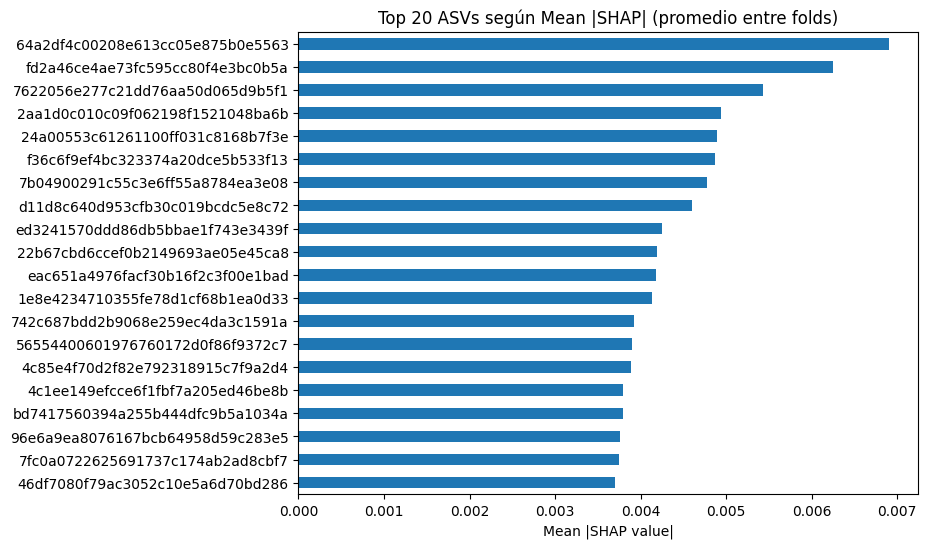

In [21]:
top_features = shap_df.head(20).index


plt.figure(figsize=(8,6))

shap_df.loc[top_features,"Mean_SHAP"].sort_values().plot(
    kind="barh"
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.title(
    "Top 20 ASVs según Mean |SHAP| (promedio entre folds)"
)

plt.show()

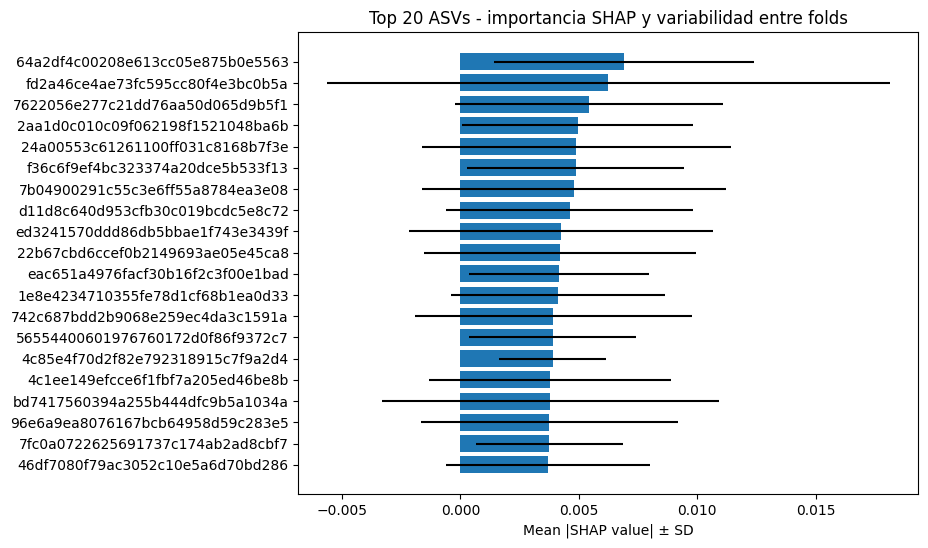

In [22]:
top = shap_df.head(20).sort_values("Mean_SHAP")

plt.figure(figsize=(8,6))

plt.barh(
    top.index,
    top["Mean_SHAP"],
    xerr=top["Std_SHAP"]
)

plt.xlabel(
    "Mean |SHAP value| ± SD"
)

plt.title(
    "Top 20 ASVs - importancia SHAP y variabilidad entre folds"
)

plt.show()

In [23]:
tax_dict_azh = pd.read_csv(
    "taxonomy.tsv",
    sep="\t"
)
tax_dict = dict(zip(
    tax_dict_azh["Feature ID"],
    tax_dict_azh["Taxon"]
))
tax_dict

{'afc7d633b31eacbcd06f9bd00fc92aba': 'd__Bacteria; p__Firmicutes; c__Negativicutes; o__Veillonellales-Selenomonadales; f__Veillonellaceae; g__Veillonella',
 'd08c784d1836f43726d1162eadd9c4a4': 'd__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Neisseriaceae; g__Neisseria',
 '58844abe1585eaed470c626af5e293c2': 'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Prevotellaceae; g__Prevotella',
 'b9678f89d81e366818a5f4e9a4dbcbf6': 'd__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Streptococcaceae; g__Streptococcus',
 '2f2af02b1b3b9b47876e1c1f5c41d976': 'd__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Streptococcaceae; g__Streptococcus',
 '3307f2605d463abcc42024cdfef4c1fe': 'd__Bacteria; p__Firmicutes; c__Bacilli; o__Lactobacillales; f__Streptococcaceae; g__Streptococcus',
 '0f36313fefd8246ebc2d63bd1b70b6f4': 'd__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Prevotellaceae; g__Prevotella; s__Prevote

In [24]:
shap_df.index = shap_df.index.map(tax_dict)
shap_df.head()

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Mean_SHAP,Std_SHAP,CV_SHAP
d__Bacteria; p__Firmicutes; c__Negativicutes; o__Veillonellales-Selenomonadales; f__Selenomonadaceae; g__uncultured; s__Mitsuokella_sp.,0.002544,0.000000,0.009938,0.006543,0.015496,0.006904,0.005474,0.792861
d__Bacteria; p__Actinobacteriota; c__Actinobacteria; o__Actinomycetales; f__Actinomycetaceae; g__Actinomyces; s__Actinomyces_graevenitzii,0.000000,0.001222,0.000000,0.030037,0.000000,0.006252,0.011902,1.903805
d__Bacteria; p__Actinobacteriota; c__Actinobacteria; o__Bifidobacteriales; f__Bifidobacteriaceae; g__Parascardovia; s__Parascardovia_denticolens,0.002928,0.013772,0.010480,0.000000,0.000000,0.005436,0.005663,1.041670
d__Bacteria; p__Proteobacteria; c__Gammaproteobacteria; o__Burkholderiales; f__Neisseriaceae; g__Kingella; s__uncultured_bacterium,0.004721,0.000000,0.000000,0.006885,0.013116,0.004944,0.004888,0.988684
d__Bacteria; p__Firmicutes; c__Clostridia; o__Lachnospirales; f__Lachnospiraceae; g__uncultured; s__Eubacterium_sp.,0.004567,0.000000,0.000000,0.002451,0.017474,0.004898,0.006515,1.330051


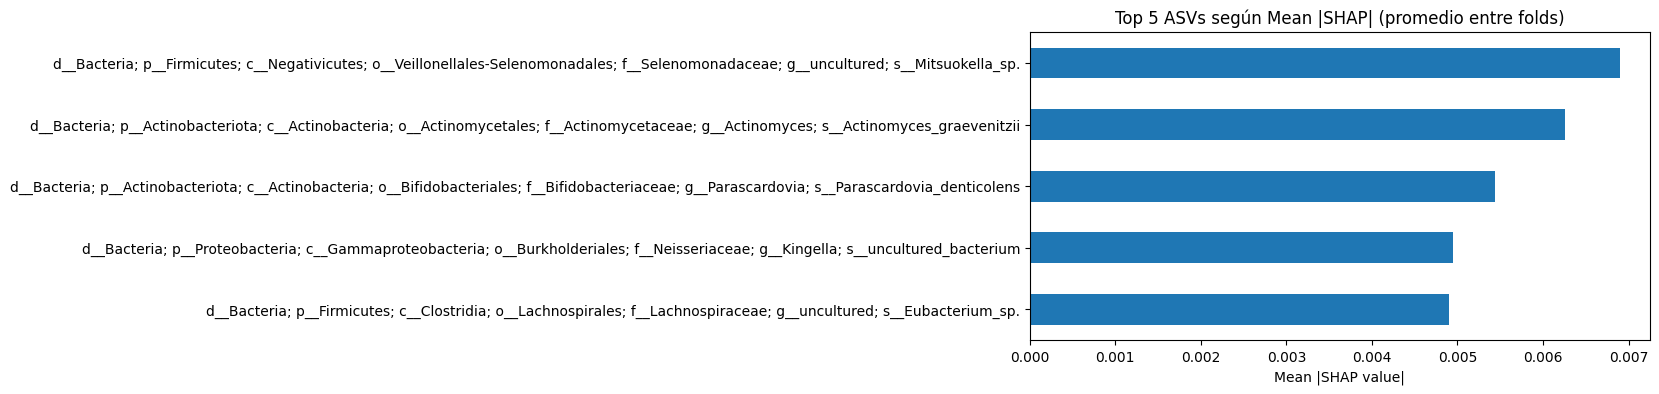

In [25]:
# 1. Ordenar por la métrica de mayor a menor y tomar los 5 primeros índices
top_5_df = shap_df.sort_values(by="Mean_SHAP", ascending=False).head(5)

# 2. Graficar
plt.figure(figsize=(8, 4))

# Ordenamos de menor a mayor para que el valor más alto quede arriba en el gráfico de barras horizontales
top_5_df["Mean_SHAP"].sort_values().plot(kind="barh")

plt.xlabel("Mean |SHAP value|")
plt.title("Top 5 ASVs según Mean |SHAP| (promedio entre folds)")
plt.tight_layout() # Evita que los nombres largos del eje Y se solapen o salgan cortados
plt.show()

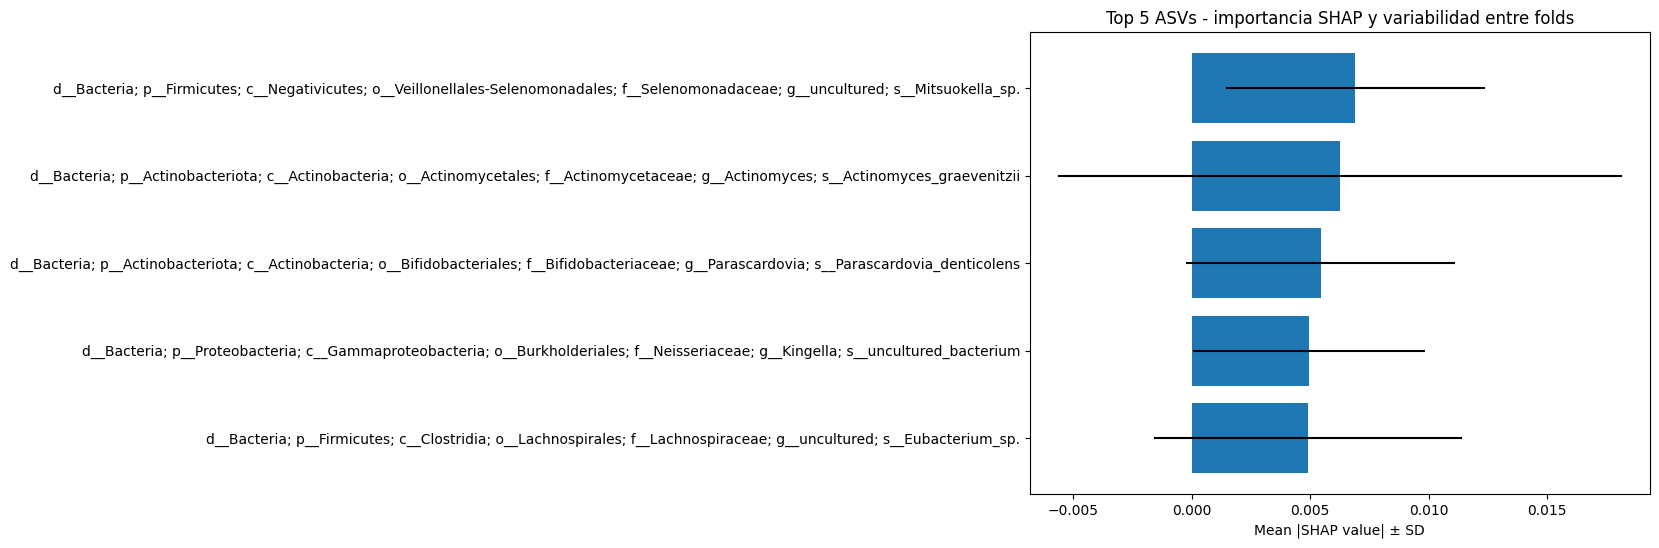

In [28]:
top = shap_df.head(5).sort_values("Mean_SHAP")

plt.figure(figsize=(8,6))

plt.barh(
    top.index,
    top["Mean_SHAP"],
    xerr=top["Std_SHAP"]
)

plt.xlabel(
    "Mean |SHAP value| ± SD"
)

plt.title(
    "Top 5 ASVs - importancia SHAP y variabilidad entre folds"
)

plt.show()